In [131]:
from __future__ import annotations

In [132]:
from IPython.display import display, HTML
display(HTML('<style>.container { width:100% !important; }</style>'))

In [133]:
import os
import datetime
import numpy as np
import sklearn.metrics
import tensorflow as tf
import sklearn.datasets
import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import seaborn as sns
sns.set_style('dark')
sns.set(rc={'figure.figsize': (10, 10), 'axes.grid': False})

In [134]:
SEED = 42

In [135]:
rng = np.random.default_rng(SEED)

In [136]:
def plot_grid(X, ncols=2, nrows=2, figsize=(10, 10), hide_axes=True):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)
    imgs = X[rng.choice(np.arange(X.shape[0]), size=ax.shape)].reshape(*ax.shape, 28, 28)
    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            ax[i, j].imshow(imgs[i, j], cmap='gray')
            if hide_axes:
                ax[i, j].get_xaxis().set_visible(False)
                ax[i, j].get_yaxis().set_visible(False)

In [137]:
def plot_grid_and_label(X, y, model, ncols=2, nrows=2, figsize=(10, 10), hide_axes=True, flatten_image=True, label_description=None):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)
    idx = rng.choice(np.arange(X.shape[0]), size=ax.shape)
    imgs, labels = X[idx], y[idx]
    inputs = imgs.reshape(-1, *imgs.shape[2:])
    
    if flatten_image:
        inputs = inputs.reshape(nrows * ncols, -1)
        
    map_label = (lambda x: x) if label_description is None else (lambda x: label_description[x])
        
    preds = np.argmax(tf.nn.softmax(model.predict(inputs)), axis=-1).reshape(nrows, ncols)
    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            ax[i, j].imshow(imgs[i, j], cmap='gray')
            ax[i, j].set_title(f'label: {map_label(labels[i, j])}, prediction: {map_label(preds[i, j])}')
            if hide_axes:
                ax[i, j].get_xaxis().set_visible(False)
                ax[i, j].get_yaxis().set_visible(False)

In [138]:
label_description = [
     'A',   'I',   'U',  'E',  'O',
    'KA',  'KI',  'KU', 'KE', 'KO',
    'SA', 'SHI',  'SU', 'SE', 'SO',
    'TA', 'CHI', 'TSU', 'TE', 'TO',
    'NA',  'NI',  'NU', 'NE', 'NO',
    'HA',  'HI',  'FU', 'HE', 'HO',
    'MA',  'MI',  'MU', 'ME', 'MO',
    'YA',         'YU',       'YO',
    'RA',  'RI',  'RU', 'RE', 'RO',
    'WA',  'II',        'EE', 'WO',
     'N',  'IT'
]

In [139]:
X, y = sklearn.datasets.fetch_openml('Kuzushiji-49', version=1, return_X_y=True, as_frame=False, parser='auto')
y = np.array(list(map(int, y)))
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_valid, y_train_valid, test_size=0.15, random_state=SEED, stratify=y_train_valid)

In [140]:
counts = { j: np.sum(y_train_valid == i) for i, j in enumerate(label_description) }

In [141]:
counts # what to do with imbalanced classes?

{'A': np.int64(5950),
 'I': np.int64(5950),
 'U': np.int64(5950),
 'E': np.int64(768),
 'O': np.int64(5950),
 'KA': np.int64(5950),
 'KI': np.int64(5950),
 'KU': np.int64(5950),
 'KE': np.int64(4659),
 'KO': np.int64(5950),
 'SA': np.int64(5950),
 'SHI': np.int64(5950),
 'SU': np.int64(5950),
 'SE': np.int64(4117),
 'SO': np.int64(3822),
 'TA': np.int64(5950),
 'CHI': np.int64(2536),
 'TSU': np.int64(5950),
 'TE': np.int64(5950),
 'TO': np.int64(5950),
 'NA': np.int64(5950),
 'NI': np.int64(5950),
 'NU': np.int64(2039),
 'NE': np.int64(2422),
 'NO': np.int64(5950),
 'HA': np.int64(5950),
 'HI': np.int64(5073),
 'FU': np.int64(5950),
 'HE': np.int64(5950),
 'HO': np.int64(1969),
 'MA': np.int64(5950),
 'MI': np.int64(3024),
 'MU': np.int64(1698),
 'ME': np.int64(3354),
 'MO': np.int64(5950),
 'YA': np.int64(5950),
 'YU': np.int64(1579),
 'YO': np.int64(5950),
 'RA': np.int64(5950),
 'RI': np.int64(5950),
 'RU': np.int64(5950),
 'RE': np.int64(5950),
 'RO': np.int64(2114),
 'WA': np.int6

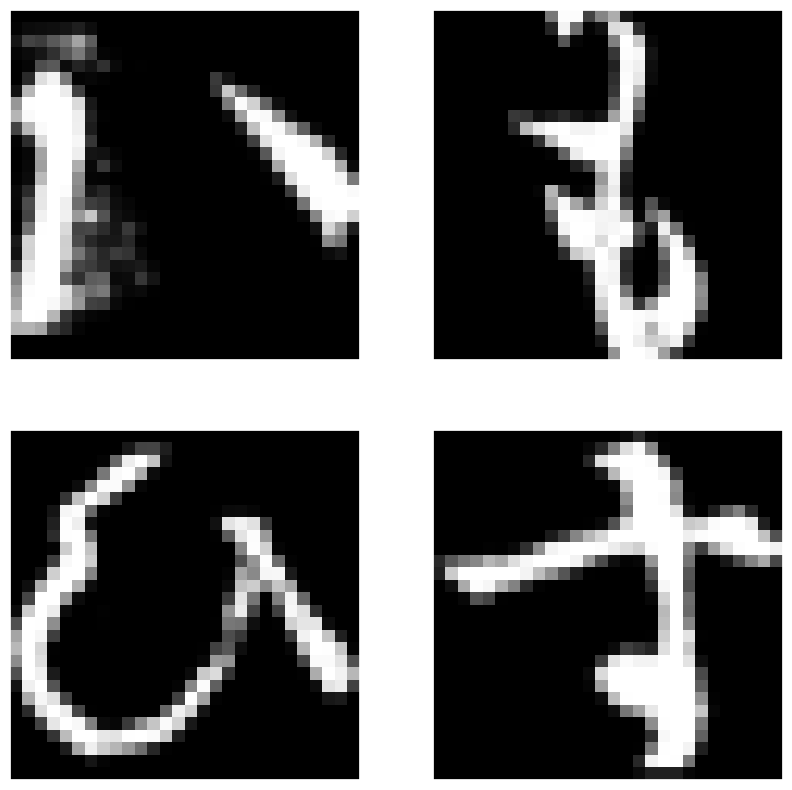

In [142]:
plot_grid(X_train)

## Flattened images
Use Dense layers

In [143]:
class Dataset(keras.utils.PyDataset):

    def __init__(self, X: np.ndarray, y: np.ndarray, batch_size: int, seed: int | None = None, shuffle: bool = False, **kwargs):
        super().__init__(**kwargs)
        self.X = X / 255.0
        self.y = y
        self.batch_size = batch_size
        self.rng = np.random.default_rng(seed)
        self.indices = np.arange(len(X))
        self.shuffle = shuffle

        self.on_epoch_end()
    
    def __len__(self):
        return -(-len(self.indices) // self.batch_size) 

    def __getitem__(self, idx):
        idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        return self.X[idx], self.y[idx]
    
    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.indices)

In [144]:
train_dataset = Dataset(X_train, y_train, 64, shuffle=True, seed=SEED)
val_dataset = Dataset(X_val, y_val, 64, shuffle=False, seed=SEED)

In [145]:
x = inputs = keras.layers.Input((784, ), name='Input')
x = keras.layers.Dense(424, name='dense1', activation='relu')(x)
x = keras.layers.Dropout(0.25, name="drop")(x)
x = keras.layers.Dense(324, name='dense2', activation='relu')(x)
x = keras.layers.Dense(len(np.unique(y_train)), name='dense3', activation='softmax')(x)

model = keras.models.Model(inputs=inputs, outputs=x, name='model_flatten')

In [146]:
model.summary()

Model: "model_flatten"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 424)            │       332,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop (Dropout)                  │ (None, 424)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 324)            │       137,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 49)             │        15,925 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 486,465 (1.86 MB)

 Trainable params: 486,465 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

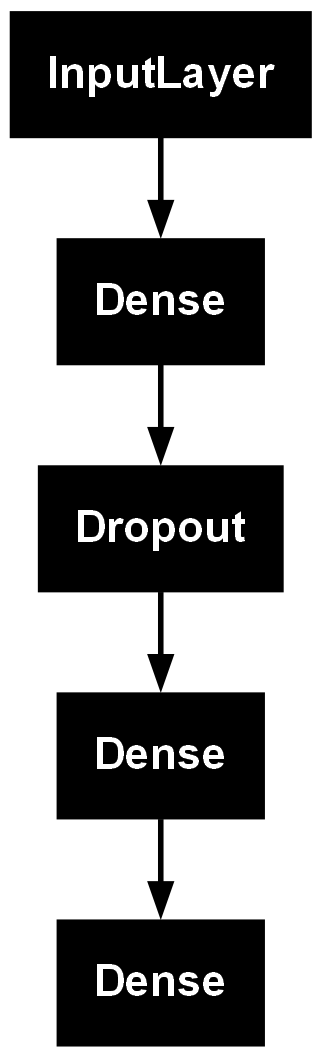

In [147]:
tf.keras.utils.plot_model(model)

In [148]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer='adam',
    metrics=['accuracy']
)

In [149]:
from sklearn.utils import class_weight

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(weights))

In [150]:
model.fit(
    train_dataset, 
    validation_data=val_dataset, 
    epochs=10, 
    class_weight=class_weights_dict
)

Epoch 1/10
3059/3059 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - accuracy: 0.7333 - loss: 0.9985 - val_accuracy: 0.8392 - val_loss: 0.5873
Epoch 2/10
3059/3059 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - accuracy: 0.8359 - loss: 0.5731 - val_accuracy: 0.8648 - val_loss: 0.4936
Epoch 3/10
3059/3059 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.8625 - loss: 0.4660 - val_accuracy: 0.8867 - val_loss: 0.4126
Epoch 4/10
3059/3059 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - accuracy: 0.8775 - loss: 0.4084 - val_accuracy: 0.8935 - val_loss: 0.3956
Epoch 5/10
3059/3059 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.8871 - loss: 0.3706 - val_accuracy: 0.8938 - val_loss: 0.3915
Epoch 6/10
3059/3059 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step - accuracy: 0.8950 - loss: 0.3402 - val_accuracy: 0.8974 - val_loss: 0.3794
Epoch 7/10
3059/3059 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - accuracy: 0.8995 - loss: 0.3250 - val_accuracy: 0.9046 - val_loss: 0.3591
Epoch 8/10
3059/3059 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - accuracy: 0.9047 - l

In [151]:
images = X_test.reshape(-1, 28, 28, 1) # normalize if needed

In [152]:
images = images / 255.0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


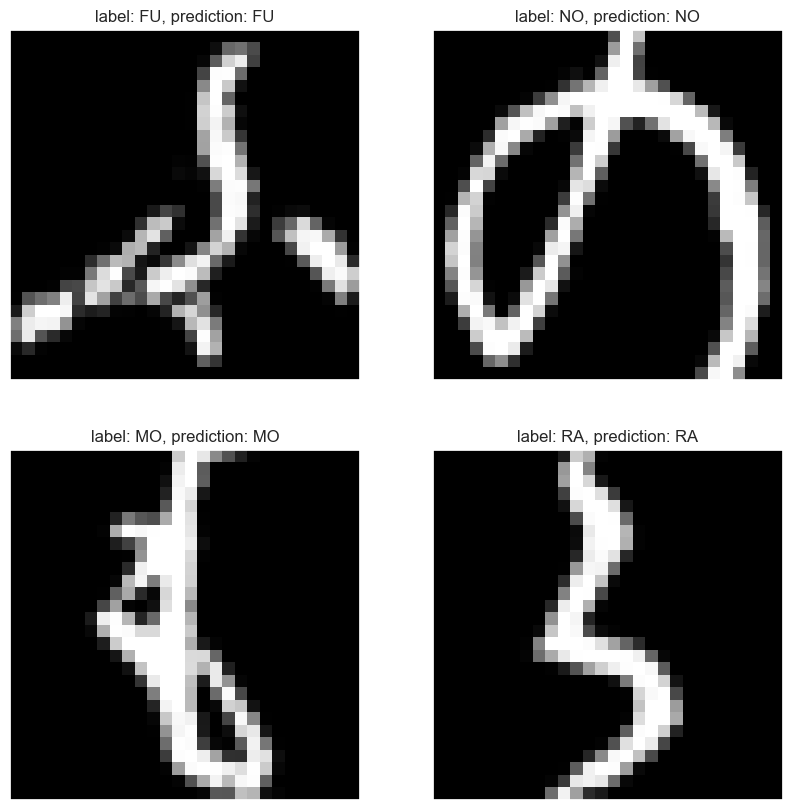

In [153]:
plot_grid_and_label(images, y_test, model, label_description=label_description)

In [154]:
X_test_norm = X_test / 255.0

In [155]:
y_pred = model.predict(X_test_norm) # make predictions
y_pred = np.argmax(y_pred, axis=1)

1270/1270 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step


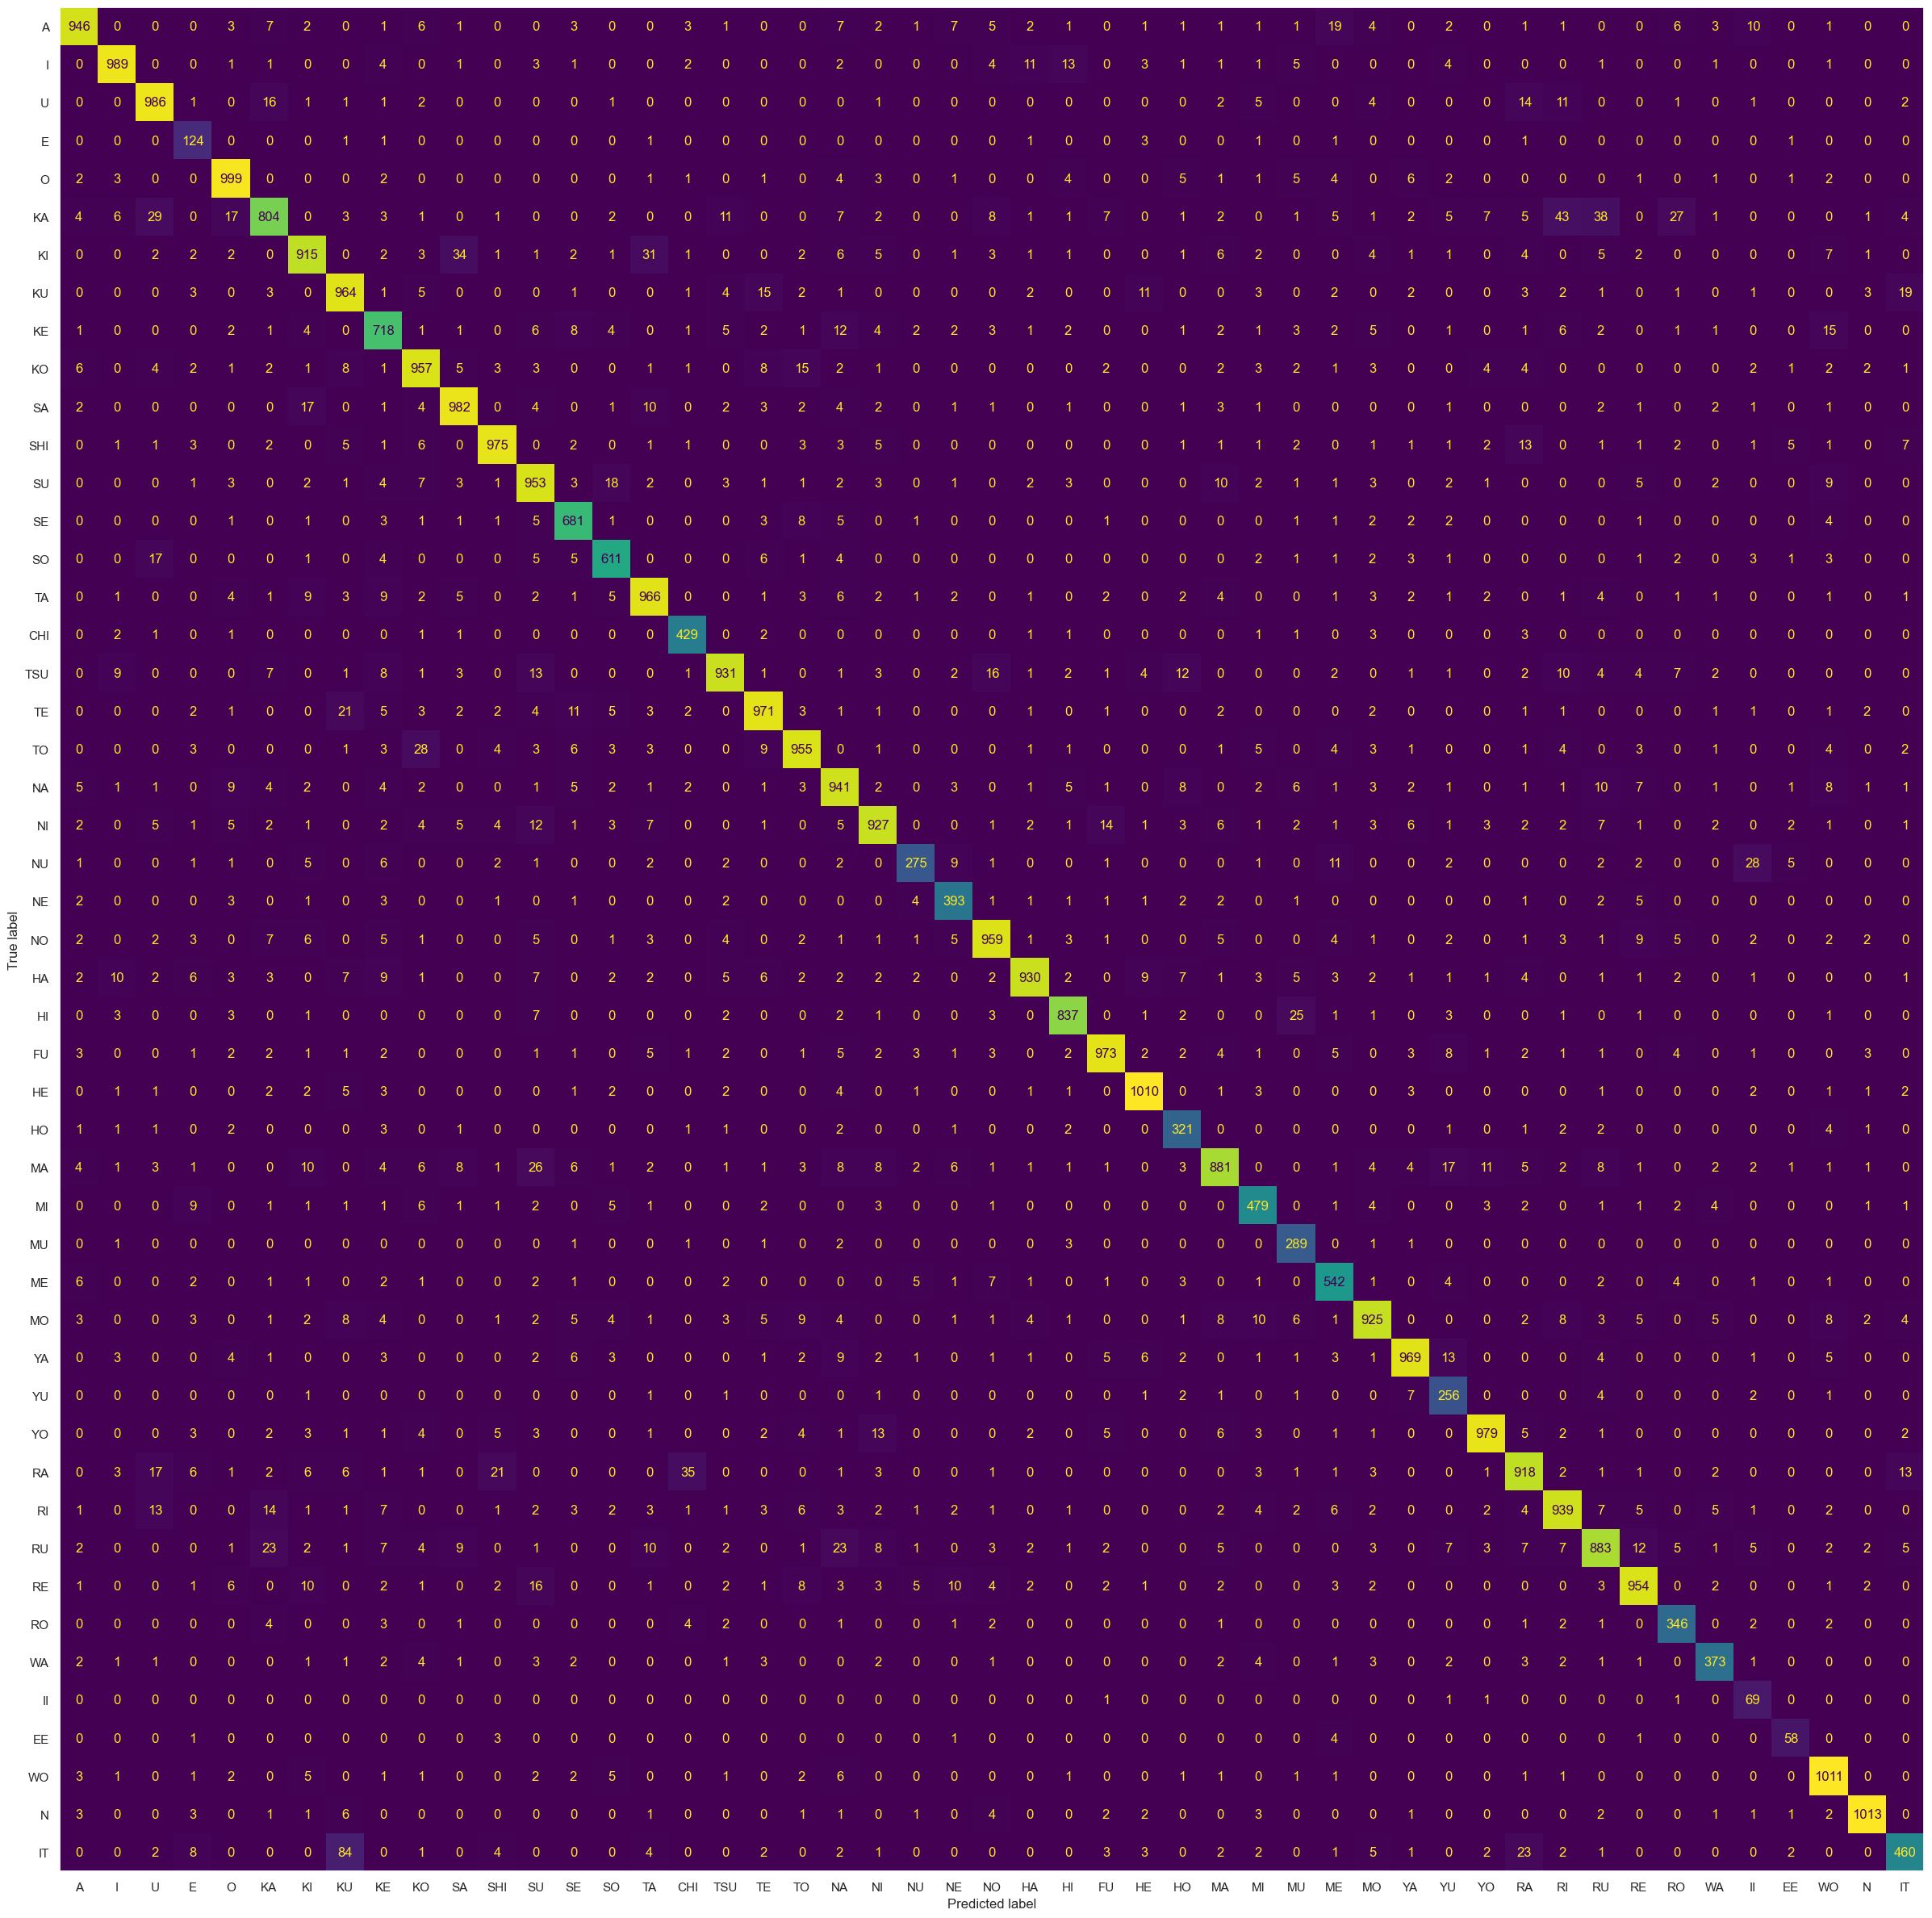

In [156]:
_, ax = plt.subplots(figsize=(30, 30))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=label_description, ax=ax, colorbar=False)

##### Balanced accuracy

In [157]:
accuracy = y_test == y_pred
np.mean([np.mean(accuracy[y_test == i]) for i in range(49)])

np.float64(0.9039899903862961)

## Actual images
Use Conv2D layers with Dense layer on top

In [46]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_val = X_val.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [47]:
train_dataset = Dataset(X_train, y_train, 64, shuffle=True, seed=SEED)
val_dataset = Dataset(X_val, y_val, 64, shuffle=False, seed=SEED)

In [69]:
x = inputs = keras.layers.Input((28, 28, 1), name='input')

x = keras.layers.Conv2D(64, kernel_size=2, padding='same', name='conv1')(x)
x = keras.layers.BatchNormalization(name='norm1')(x)
x = keras.layers.Activation(activation='relu', name='activation1')(x)
x = keras.layers.Dropout(0.25, name='drop1')(x)
x = keras.layers.MaxPool2D(2, name='pool1')(x)

x = keras.layers.Conv2D(64, kernel_size=2, padding='same', name='conv2')(x)
x = keras.layers.BatchNormalization(name='norm2')(x)
x = keras.layers.Activation(activation='relu', name='activation2')(x)
x = keras.layers.Dropout(0.25, name='drop2')(x)
x = keras.layers.MaxPool2D(2, name='pool2')(x)

x = keras.layers.Flatten(name='flatten')(x)
x = keras.layers.Dense(len(np.unique(y_train)), activation='softmax', name='dense')(x)

model = keras.models.Model(inputs=inputs, outputs=x, name='model')

In [70]:
model.summary()

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 28, 28, 64)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm1 (BatchNormalization)      │ (None, 28, 28, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation1 (Activation)        │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm2 (BatchNormalization)      │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation2 (Activation)        │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 49)             │       153,713 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 170,993 (667.94 KB)

 Trainable params: 170,737 (666.94 KB)

 Non-trainable params: 256 (1.00 KB)

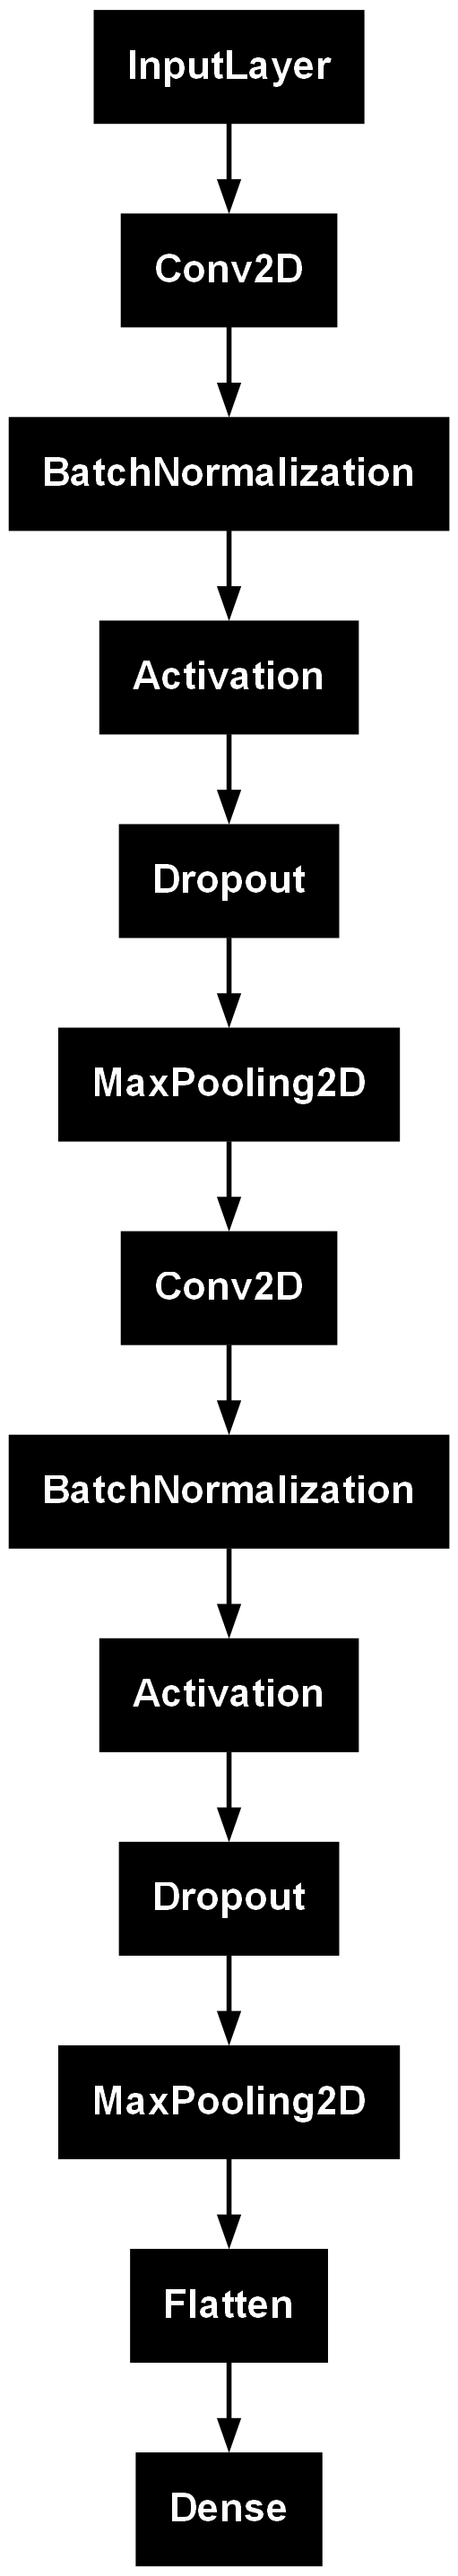

In [71]:
tf.keras.utils.plot_model(model)

In [74]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    train_dataset, 
    validation_data=val_dataset, 
    epochs=10, 
    class_weight=class_weights_dict
)

Epoch 1/10


3059/3059 ━━━━━━━━━━━━━━━━━━━━ 252s 82ms/step - accuracy: 0.8099 - loss: 0.7274 - val_accuracy: 0.8777 - val_loss: 0.5248
Epoch 2/10
3059/3059 ━━━━━━━━━━━━━━━━━━━━ 259s 85ms/step - accuracy: 0.8923 - loss: 0.3801 - val_accuracy: 0.9085 - val_loss: 0.3954
Epoch 3/10
3059/3059 ━━━━━━━━━━━━━━━━━━━━ 265s 87ms/step - accuracy: 0.9127 - loss: 0.3021 - val_accuracy: 0.9123 - val_loss: 0.3736
Epoch 4/10
3059/3059 ━━━━━━━━━━━━━━━━━━━━ 267s 87ms/step - accuracy: 0.9232 - loss: 0.2581 - val_accuracy: 0.9222 - val_loss: 0.3230
Epoch 5/10
3059/3059 ━━━━━━━━━━━━━━━━━━━━ 282s 92ms/step - accuracy: 0.9313 - loss: 0.2264 - val_accuracy: 0.9234 - val_loss: 0.3056
Epoch 6/10
3059/3059 ━━━━━━━━━━━━━━━━━━━━ 276s 90ms/step - accuracy: 0.9364 - loss: 0.2055 - val_accuracy: 0.9277 - val_loss: 0.2873
Epoch 7/10
3059/3059 ━━━━━━━━━━━━━━━━━━━━ 257s 84ms/step - accuracy: 0.9401 - loss: 0.1904 - val_accuracy: 0.9235 - val_loss: 0.3036
Epoch 8/10
3059/3059 ━━━━━━━━━━━━━━━━━━━━ 264s 86ms/step - accuracy: 0.9438 - lo

In [81]:
images = X_test.reshape(-1, 28, 28, 1) # normalize if needed

In [82]:
images = images / 255.0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


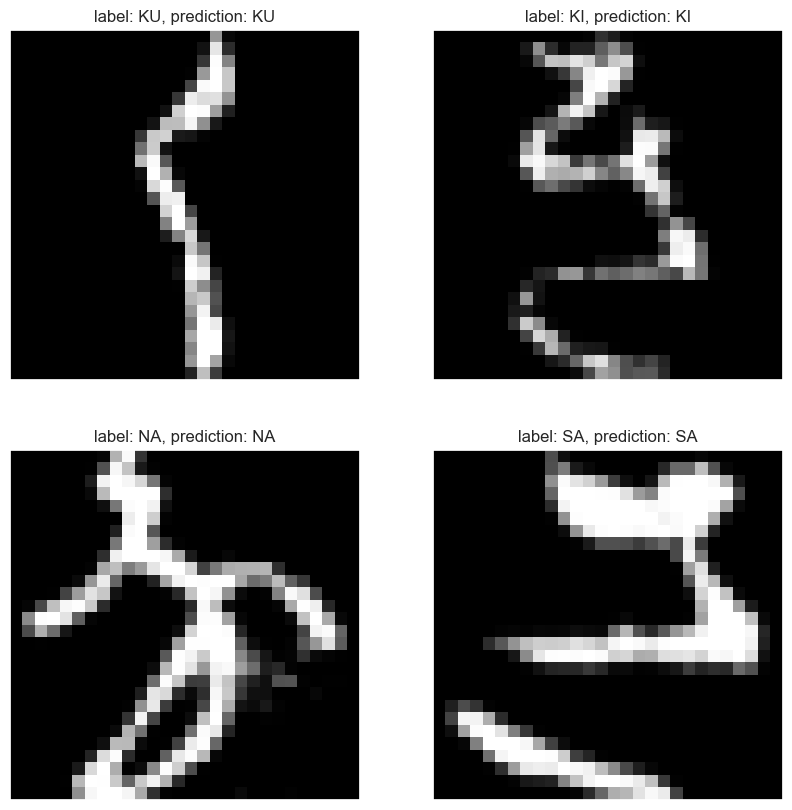

In [83]:
plot_grid_and_label(images, y_test, model, label_description=label_description, flatten_image=False)

In [78]:
y_pred = model.predict(X_test_norm) # make predictions
y_pred = np.argmax(y_pred, axis=1)

1270/1270 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step


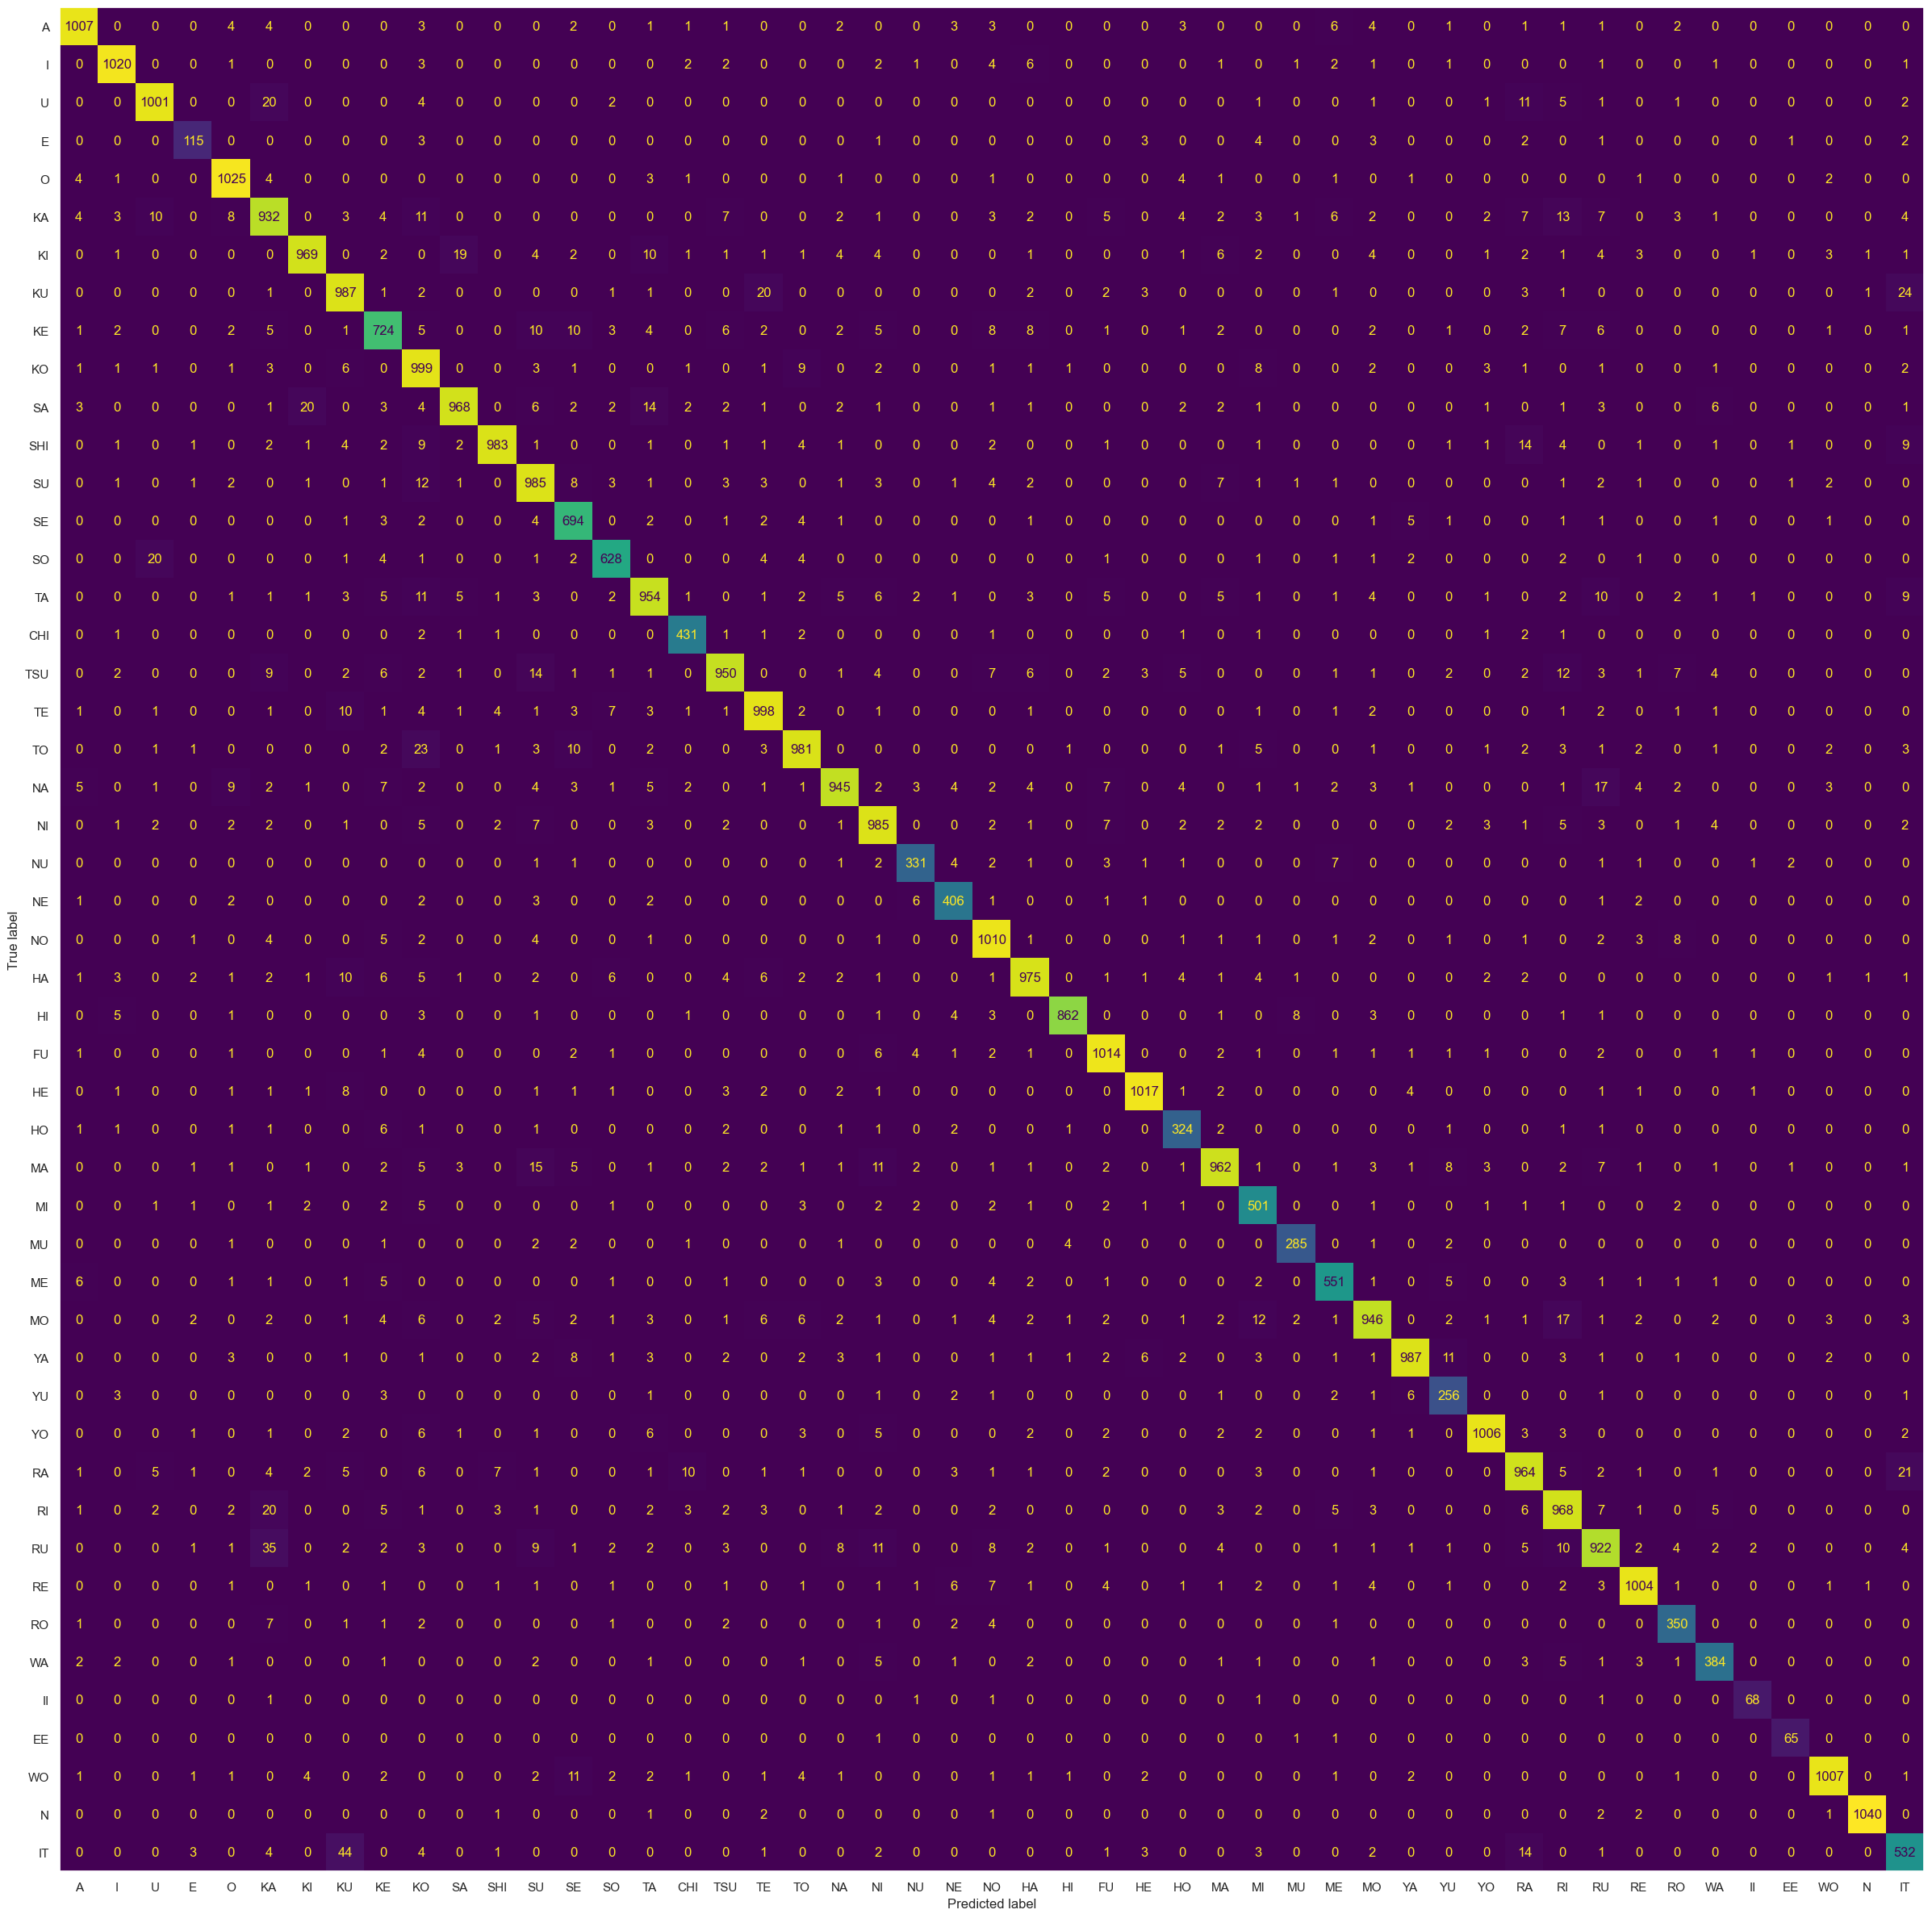

In [79]:
_, ax = plt.subplots(figsize=(30, 30))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=label_description, ax=ax, colorbar=False)

##### Balanced accuracy

In [80]:
accuracy = y_test == y_pred
np.mean([np.mean(accuracy[y_test == i]) for i in range(49)])

np.float64(0.9336887103597712)